In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

df = pd.read_parquet("../data/processed/nyc_taxi_cleaned.parquet")

# Vorbereitung der Daten
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])

df["month"] = df["tpep_pickup_datetime"].dt.to_period("M")
df["hour"] = df["tpep_pickup_datetime"].dt.hour
#display(df.head())

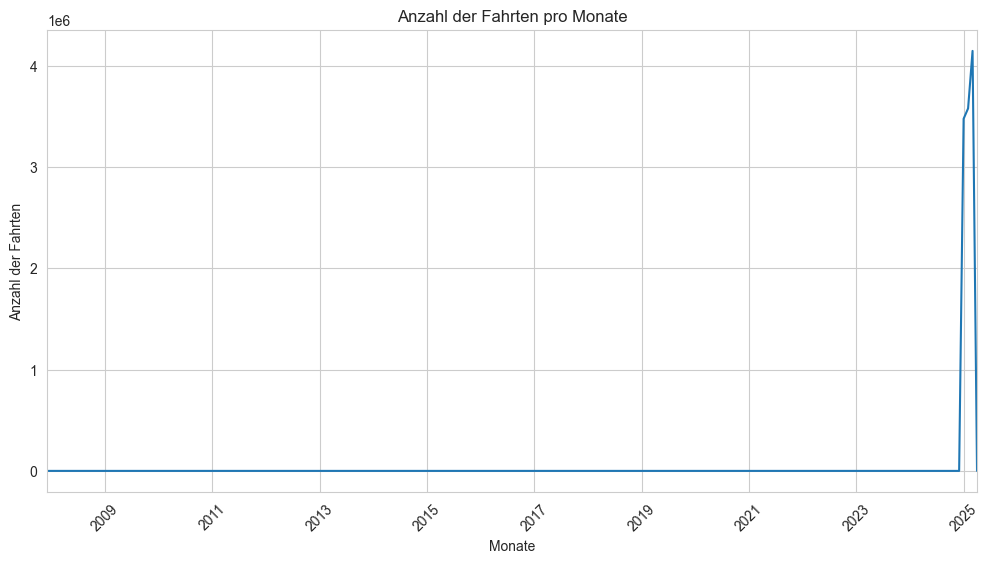

In [16]:
#Anzahl der Fahrten pro Monate

monthly = df.groupby("month").size()

monthly.plot()

plt.title("Anzahl der Fahrten pro Monate")
plt.xlabel("Monate")
plt.ylabel("Anzahl der Fahrten")

plt.xticks(rotation=45)
plt.show()

In [ ]:
monthly_df = monthly.reset_index(name="count")

sns.lineplot(data=monthly_df, x="month", y="count")

plt.title("Evolution des trajets (mensuel)")
plt.xticks(rotation=45)

plt.show()

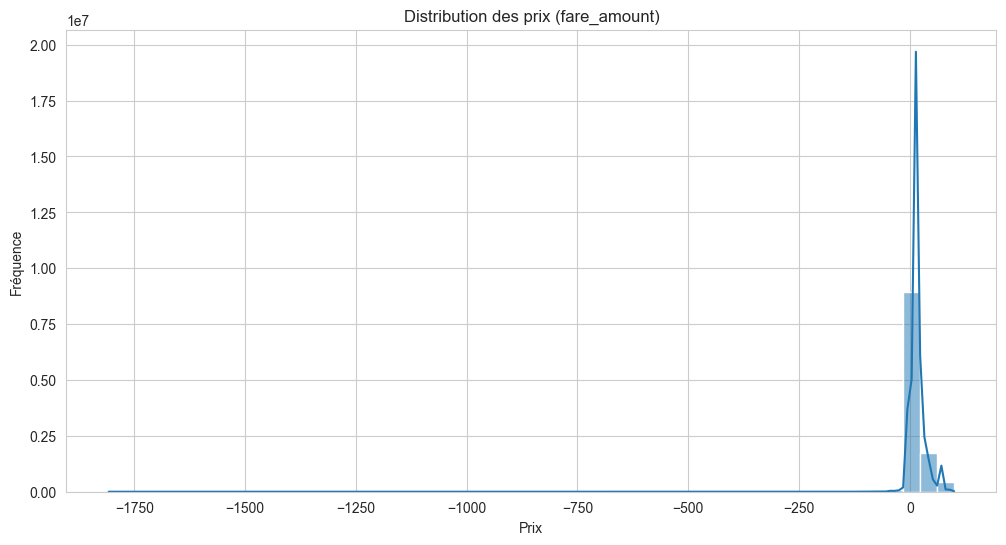

In [5]:
sns.histplot(df[df["fare_amount"] < 100]["fare_amount"], bins=50, kde=True)
plt.title("Distribution des prix (fare_amount)")
plt.xlabel("Prix")
plt.ylabel("Fréquence")

plt.show()

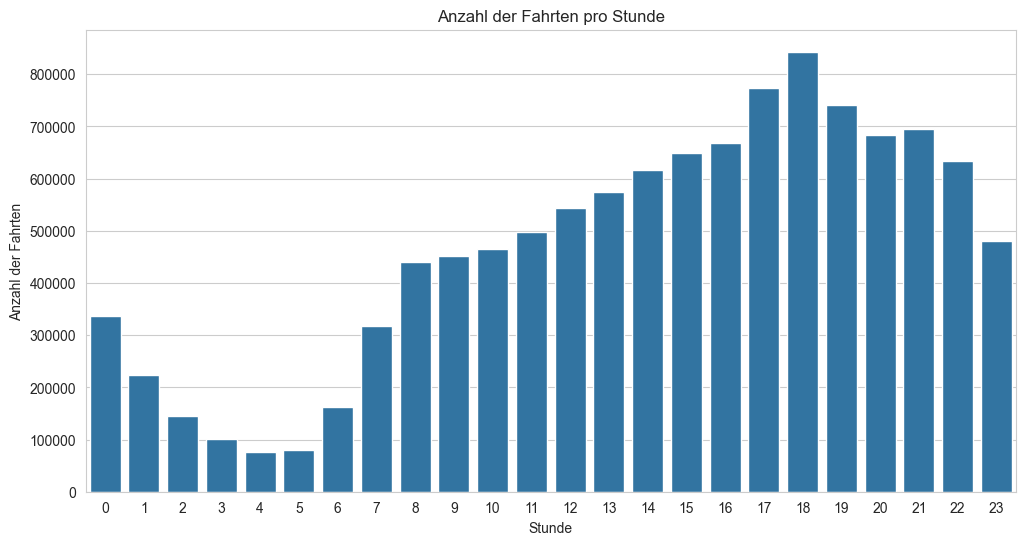

In [6]:
# Anzahl der Fahrten pro Stunde
hourly = df["hour"].value_counts().sort_index()

sns.barplot(x=hourly.index, y=hourly.values)

plt.title("Anzahl der Fahrten pro Stunde")
plt.xlabel("Stunde")
plt.ylabel("Anzahl der Fahrten")

plt.show()

In [ ]:
# Einkomen pro monate

revenue_month = df.groupby("month")["fare_amount"].sum().reset_index()

sns.lineplot(data=revenue_month, x="month", y="fare_amount")

plt.title("Einkomen pro Monate")
plt.xticks(rotation=45)

plt.show()

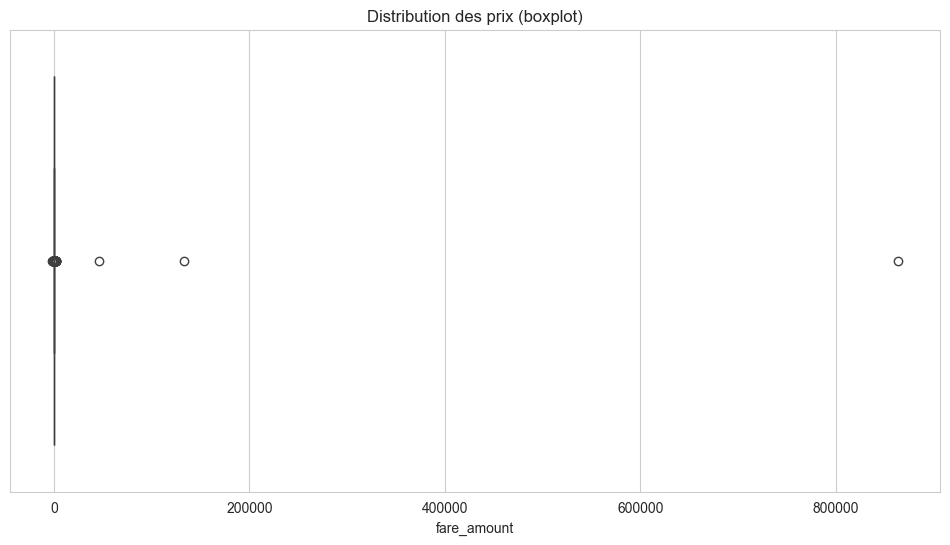

In [8]:
sns.boxplot(x=df["fare_amount"])

plt.title("Distribution des prix (boxplot)")
plt.show()

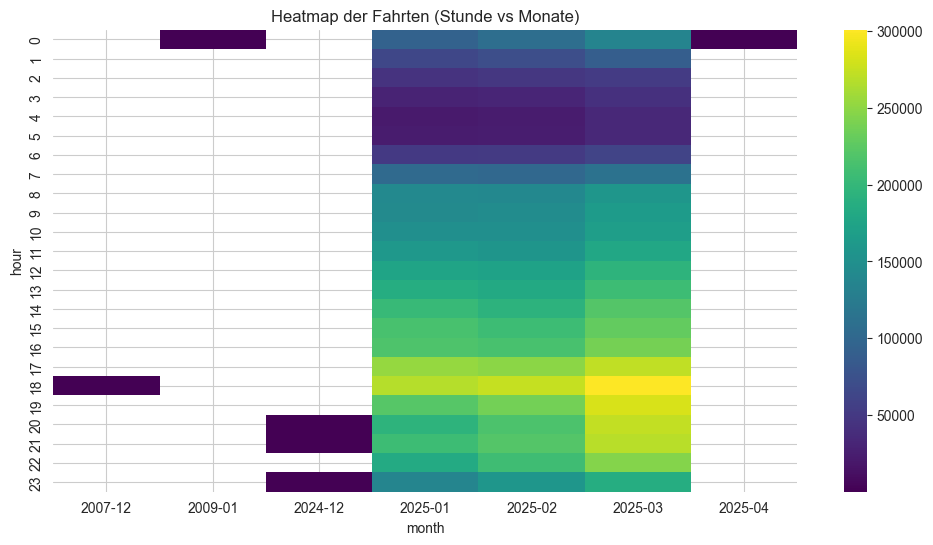

In [14]:
pivot = df.groupby(["hour", "month"]).size().unstack()

sns.heatmap(pivot, cmap="viridis")

plt.title("Heatmap der Fahrten (Stunde vs Monate)")
plt.show()

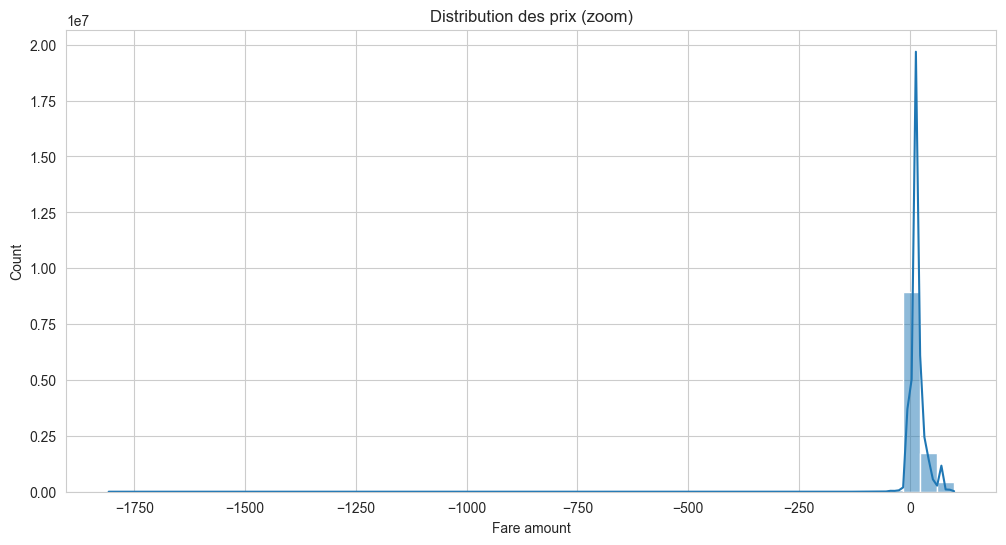

In [10]:
plt.figure(figsize=(12,6))

sns.histplot(df[df["fare_amount"] < 100]["fare_amount"], bins=50, kde=True)

plt.title("Distribution des prix (zoom)")
plt.xlabel("Fare amount")

plt.show()